In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
data_path = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-06-trees/CreditScoring.csv'

In [3]:
df = pd.read_csv(data_path)
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [4]:
df.columns = df.columns.str.lower()

In [5]:
df.head()


,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [6]:
status_values = {
    1: 'ok',
    2: 'default',
    0: 'unk'
}

df.status = df.status.map(status_values)

In [7]:
home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}

df.home = df.home.map(home_values)

marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}

df.marital = df.marital.map(marital_values)

records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}

df.records = df.records.map(records_values)

job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}

df.job = df.job.map(job_values)

In [8]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910


In [9]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [10]:
for c in ['income', 'assets', 'debt']:
    df[c] = df[c].replace(to_replace=99999999, value=np.nan)

In [11]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4421.0,4408.0,4437.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,131.0,5403.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11573.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


In [12]:
df = df[df.status != "unk"].reset_index(drop=True)

In [13]:
df

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4449,default,1,rent,60,39,married,no,fixed,69,92.0,0.0,0.0,900,1020
4450,ok,22,owner,60,46,married,no,fixed,60,75.0,3000.0,600.0,950,1263
4451,default,0,owner,24,37,married,no,partime,60,90.0,3500.0,0.0,500,963
4452,ok,0,rent,48,23,single,no,freelance,49,140.0,0.0,0.0,550,550


In [14]:
from sklearn.model_selection import train_test_split

In [15]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=11, shuffle=True)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=11, shuffle=True)


In [16]:
df_train.reset_index(drop=True, inplace=True)
df_val.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)
df_full_train.reset_index(drop=True, inplace=True)

In [17]:
y_train = (df_train.status == 'default').astype('int').values
y_full_train = (df_full_train.status == 'default').astype('int').values
y_val = (df_val.status == 'default').astype('int').values
y_test = (df_test.status == 'default').astype('int').values

In [18]:
del df_train['status']
del df_test['status']
del df_val['status']

In [19]:
df_train.head()

,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,10,owner,36,36,married,no,freelance,75,0.0,10000.0,0.0,1000,1400
1,6,parents,48,32,single,yes,fixed,35,85.0,0.0,0.0,1100,1330
2,1,parents,48,40,married,no,fixed,75,121.0,0.0,0.0,1320,1600
3,1,parents,48,23,single,no,partime,35,72.0,0.0,0.0,1078,1079
4,5,owner,36,46,married,no,freelance,60,100.0,4000.0,0.0,1100,1897


## 6.03 Decision trees

In [20]:
def assess_risk(client):
    if client['records'] == 'yes':
        if client['job'] == 'partime':
            return 'default'
        else:
            return 'ok'
    else:
        if client['assets'] > 6_000:
            return 'ok'
        else:
            return 'default'


In [21]:
xi = df_train.iloc[2].to_dict()
assess_risk(xi)

'default'

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score, roc_curve

In [23]:
train_dicts = df_train.fillna(0).to_dict(orient='records')

In [24]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

In [25]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [26]:
val_dicts = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dicts)
y_hat = dt.predict_proba(X_val)[:,1]
roc_auc_score(y_hat, y_val)

0.6636643746756616

In [27]:
y_hat = dt.predict_proba(X_train)[:,1]
roc_auc_score(y_hat, y_train)

1.0

In [28]:
y_hat = dt.predict_proba(X_val)[:,1]
roc = roc_curve(y_val, y_hat)

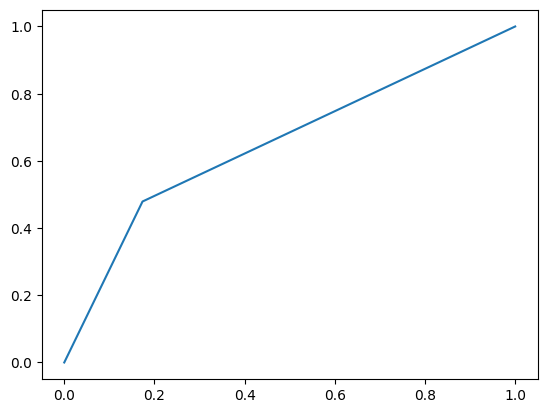

In [29]:
plt.plot(roc[0], roc[1])

In [30]:
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [31]:
y_hat = dt.predict_proba(X_train)[:,1]
auc = roc_auc_score(y_train, y_hat)
print("Train: ", auc)

y_hat = dt.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_val, y_hat)
print("Val: ", auc)

Train:  0.7761016984958594
Val:  0.7389079944782155


In [32]:
from sklearn.tree import export_text

In [33]:
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- records=yes <= 0.50
|   |--- job=partime <= 0.50
|   |   |--- income <= 74.50
|   |   |   |--- class: 0
|   |   |--- income >  74.50
|   |   |   |--- class: 0
|   |--- job=partime >  0.50
|   |   |--- assets <= 8750.00
|   |   |   |--- class: 1
|   |   |--- assets >  8750.00
|   |   |   |--- class: 0
|--- records=yes >  0.50
|   |--- seniority <= 6.50
|   |   |--- amount <= 862.50
|   |   |   |--- class: 0
|   |   |--- amount >  862.50
|   |   |   |--- class: 1
|   |--- seniority >  6.50
|   |   |--- income <= 103.50
|   |   |   |--- class: 1
|   |   |--- income >  103.50
|   |   |   |--- class: 0



# 6.4 Decision tree learning algorithm

In [34]:
data = [
    [8000, 'default'],
    [2000, 'default'],
    [   0, 'default'],
    [5000, 'ok'],
    [5000, 'ok'],
    [4000, 'ok'],
    [9000, 'ok'],
    [3000, 'default'],
]

df_example = pd.DataFrame(data, columns=['assets','status'])
df_example

,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


In [35]:
Ts = [0, 2000,3000, 4000, 5000, 8000]

In [36]:
from IPython.display import display

In [37]:
for T in Ts:
    print(T)
    df_left = df_example[df_example.assets <= T]
    df_right = df_example[df_example.assets > T]
    display(df_left)
    print(df_left.status.value_counts(normalize=True))
    display(df_right)
    print(df_right.status.value_counts(normalize=True))

0


,assets,status
2,0,default


status
default    1.0
Name: proportion, dtype: float64


,assets,status
0,8000,default
1,2000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64
2000


,assets,status
1,2000,default
2,0,default


status
default    1.0
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64
3000


,assets,status
1,2000,default
2,0,default
7,3000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok


status
ok         0.8
default    0.2
Name: proportion, dtype: float64
4000


,assets,status
1,2000,default
2,0,default
5,4000,ok
7,3000,default


status
default    0.75
ok         0.25
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
6,9000,ok


status
ok         0.75
default    0.25
Name: proportion, dtype: float64
5000


,assets,status
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,status
0,8000,default
6,9000,ok


status
default    0.5
ok         0.5
Name: proportion, dtype: float64
8000


,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64


,assets,status
6,9000,ok


status
ok    1.0
Name: proportion, dtype: float64


## 6.05 Decision trees parameter tuning

In [38]:
for d in [1, 2, 3, 4, 5, 6, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=d)
    dt.fit(X_train, y_train)

    y_pred = dt.predict_proba(X_val)[:,1]
    auc = roc_auc_score(y_val, y_pred)

    print(f"{d}-> {auc:.3f}")

1-> 0.606
2-> 0.669
3-> 0.739
4-> 0.761
5-> 0.766
6-> 0.762
15-> 0.669
20-> 0.658
None-> 0.659


- Even though depth 4, 5, and 6 give very similar results, but using depth of 4 is probably better because the model is simpler

In [39]:
scores = []

for d in [4, 5, 6, 7, 10, 15, 20, None]:
    for s in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)

        dt.fit(X_train, y_train)
        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((d, s, auc))

In [40]:
df_scores = pd.DataFrame(scores, columns=['max_depth','min_samples_leaf', 'auc'])
df_scores.head()

,max_depth,min_samples_leaf,auc
0,4.0,1,0.761283
1,4.0,2,0.761283
2,4.0,5,0.761283
3,4.0,10,0.761283
4,4.0,15,0.763726


In [41]:
df_scores.sort_values(by='auc', ascending=False)

,max_depth,min_samples_leaf,auc
40,10.0,15,0.789594
67,NaN,15,0.787657
58,20.0,15,0.785825
49,15.0,15,0.785668
41,10.0,20,0.785341
...,...,...,...
53,15.0,500,0.679842
71,NaN,500,0.679842
54,20.0,1,0.662932
63,NaN,1,0.657050


In [42]:
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', columns=['max_depth'],
                                values=['auc']
)
df_scores_pivot.round(3)

auc                                                 
max_depth           NaN   4.0    5.0    6.0    7.0    10.0   15.0   20.0
min_samples_leaf                                                        
1                 0.657  0.761  0.767  0.756  0.730  0.689  0.655  0.663
2                 0.687  0.761  0.767  0.756  0.747  0.716  0.695  0.697
5                 0.712  0.761  0.768  0.759  0.756  0.729  0.717  0.719
10                0.761  0.761  0.762  0.778  0.765  0.766  0.762  0.758
15                0.788  0.764  0.772  0.785  0.780  0.790  0.786  0.786
20                0.782  0.761  0.774  0.774  0.779  0.785  0.781  0.782
100               0.780  0.756  0.763  0.776  0.780  0.780  0.780  0.780
200               0.768  0.747  0.759  0.768  0.768  0.768  0.768  0.768
500               0.680  0.680  0.680  0.680  0.680  0.680  0.680  0.680

<Axes: xlabel='None-max_depth', ylabel='min_samples_leaf'>

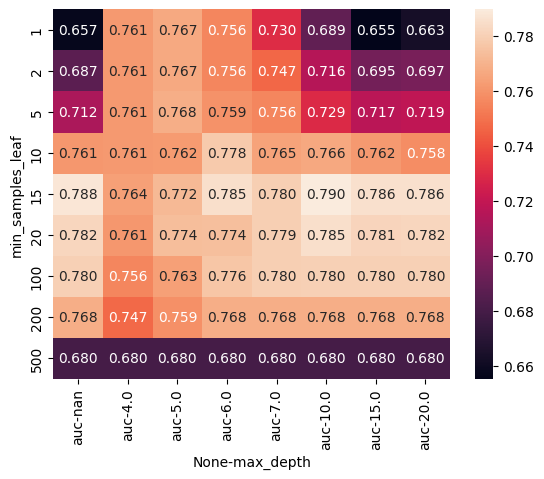

In [43]:
sns.heatmap(df_scores_pivot, annot=True, fmt='.3f')

In [44]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

## 6.6 Ensemble and random forest

In [45]:
from sklearn.ensemble import RandomForestClassifier

In [46]:
rf = RandomForestClassifier(n_estimators=10, random_state=1)
rf.fit(X_train, y_train)
y_pred = rf.predict_proba(X_val)[:,1]
roc_auc_score(y_val, y_pred)

0.7744726453706618

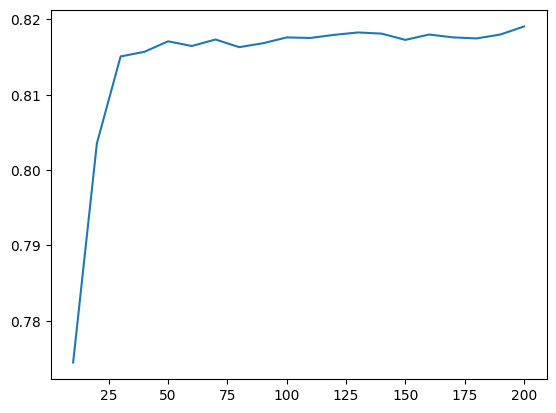

In [47]:
auc_scores = []
for n in range(10,201,10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict_proba(X_val)[:,1]
    auc_score = roc_auc_score(y_val, y_pred)
    auc_scores.append(auc_score)

plt.plot(range(10,201,10), auc_scores)


- 50 ensembles is more or less optimal

In [48]:
auc_scores = []
for d in [5, 10, 15]:
    for n in range(10,201,10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=d,
                                    random_state=1)
        rf.fit(X_train, y_train)
        y_pred = rf.predict_proba(X_val)[:,1]
        auc_score = roc_auc_score(y_val, y_pred)
        auc_scores.append((d, n, auc_score))

In [49]:
df = pd.DataFrame(auc_scores, columns=["depth", "n_estimators", "auc"])

In [50]:
df_pivot = df.pivot(index='n_estimators', columns='depth', values='auc')

<Axes: xlabel='n_estimators'>

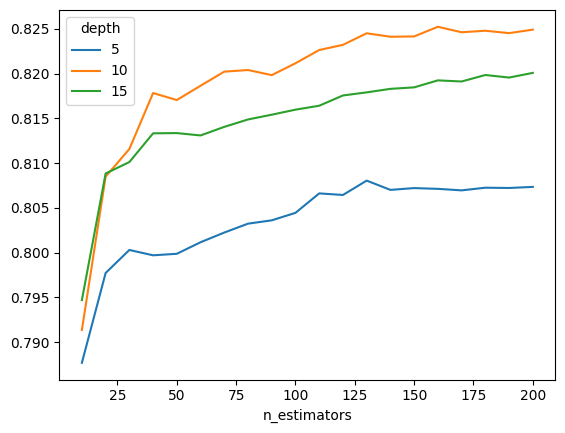

In [51]:
fig, ax = plt.subplots()
df_pivot.plot(kind='line', ax=ax)

In [52]:
max_depth = 10

In [53]:
auc_scores = []
for s in [1, 3, 5, 10, 50]:
    for n in range(10,201,10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=max_depth,
                                    random_state=1,
                                    min_samples_leaf=s,
                                    
                                    )
        rf.fit(X_train, y_train)
        y_pred = rf.predict_proba(X_val)[:,1]
        auc_score = roc_auc_score(y_val, y_pred)
        auc_scores.append((s, n, auc_score))

In [54]:
df = pd.DataFrame(auc_scores, columns=["leaves", "n_estimators", "auc"])
df_pivot = df.pivot(index='n_estimators', columns='leaves', values='auc')

<Axes: xlabel='n_estimators'>

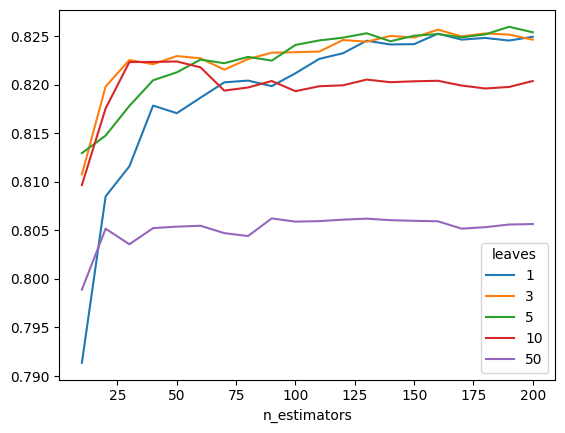

In [55]:
fig, ax = plt.subplots()
df_pivot.plot(kind='line', ax=ax)

In [56]:
min_samples_leaf = 3

In [57]:
rf = RandomForestClassifier(n_estimators=100,
                            max_depth=max_depth,
                            random_state=1,
                            min_samples_leaf=min_samples_leaf,
                            
                            )
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## 6.07 Gradient boosting and XGBoost

In [58]:
import xgboost as xgb

In [59]:
features = dv.get_feature_names_out().tolist()
dtrain = xgb.DMatrix(X_train,label=y_train,feature_names=features)
features = dv.get_feature_names_out().tolist()
dval = xgb.DMatrix(X_val,label=y_val,feature_names=features)

In [60]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight':1,
    'objective': 'binary:logistic',
    'nthread':1,
    'seed':1,
    'verbosity':2,

}
model = xgb.train(xgb_params, dtrain, num_boost_round=10, )

In [61]:
y_pred = model.predict(dval)

In [62]:
roc_auc_score(y_val, y_pred)

0.8118506454190986

In [63]:
watch_list = [(dtrain, 'train'), (dval, 'val')]

In [64]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight':1,
    'objective': 'binary:logistic',
    'nthread':1,
    'eval_metric': 'auc',
    'seed':1,
    'verbosity':2,

}

results = {}
model = xgb.train(xgb_params,
                  dtrain,
                  verbose_eval=10,
                  evals=watch_list,
                  evals_result=results,
                  num_boost_round=200)

[0]	train-auc:0.86653	val-auc:0.77999
[10]	train-auc:0.95512	val-auc:0.81115
[20]	train-auc:0.97648	val-auc:0.81877
[30]	train-auc:0.98844	val-auc:0.81613
[40]	train-auc:0.99393	val-auc:0.81407
[50]	train-auc:0.99723	val-auc:0.81276
[60]	train-auc:0.99861	val-auc:0.81244
[70]	train-auc:0.99962	val-auc:0.81243
[80]	train-auc:0.99989	val-auc:0.81359
[90]	train-auc:0.99998	val-auc:0.81038
[100]	train-auc:0.99999	val-auc:0.80842
[110]	train-auc:1.00000	val-auc:0.80764
[120]	train-auc:1.00000	val-auc:0.80750
[130]	train-auc:1.00000	val-auc:0.80496
[140]	train-auc:1.00000	val-auc:0.80379
[150]	train-auc:1.00000	val-auc:0.80561
[160]	train-auc:1.00000	val-auc:0.80604
[170]	train-auc:1.00000	val-auc:0.80650
[180]	train-auc:1.00000	val-auc:0.80567
[190]	train-auc:1.00000	val-auc:0.80619
[199]	train-auc:1.00000	val-auc:0.80602


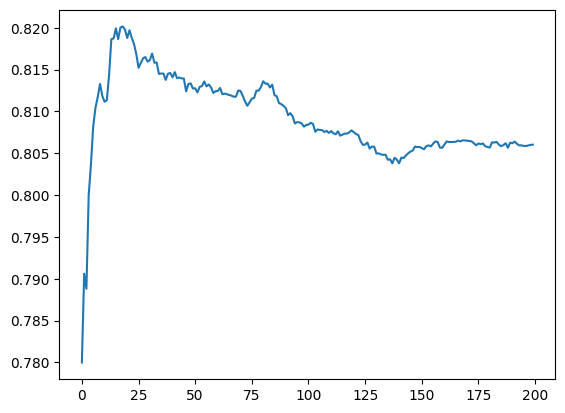

In [65]:
plt.plot(np.arange(len(results['val']['auc'])),results['val']['auc'])
#plt.plot(np.arange(len(results['train']['auc'])),results['train']['auc'])

## 6.08 XGBoost Parameter Tuning

In [66]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight':1,
    'objective': 'binary:logistic',
    'nthread':1,
    'eval_metric': 'auc',
    'seed':1,
    'verbosity':2,

}

results = {}
model = xgb.train(xgb_params,
                  dtrain,
                  verbose_eval=10,
                  evals=watch_list,
                  evals_result=results,
                  num_boost_round=200)

[0]	train-auc:0.86653	val-auc:0.77999
[10]	train-auc:0.95512	val-auc:0.81115
[20]	train-auc:0.97648	val-auc:0.81877
[30]	train-auc:0.98844	val-auc:0.81613
[40]	train-auc:0.99393	val-auc:0.81407
[50]	train-auc:0.99723	val-auc:0.81276
[60]	train-auc:0.99861	val-auc:0.81244
[70]	train-auc:0.99962	val-auc:0.81243
[80]	train-auc:0.99989	val-auc:0.81359
[90]	train-auc:0.99998	val-auc:0.81038
[100]	train-auc:0.99999	val-auc:0.80842
[110]	train-auc:1.00000	val-auc:0.80764
[120]	train-auc:1.00000	val-auc:0.80750
[130]	train-auc:1.00000	val-auc:0.80496
[140]	train-auc:1.00000	val-auc:0.80379
[150]	train-auc:1.00000	val-auc:0.80561
[160]	train-auc:1.00000	val-auc:0.80604
[170]	train-auc:1.00000	val-auc:0.80650
[180]	train-auc:1.00000	val-auc:0.80567
[190]	train-auc:1.00000	val-auc:0.80619
[199]	train-auc:1.00000	val-auc:0.80602


In [67]:
from copy import deepcopy

In [68]:
results_opt = {}

for eta in [0.1,0.2, 0.3, 0.5]:
    
    xgb_params = {
        'eta': eta,
        'max_depth': 6,
        'min_child_weight':1,
        'objective': 'binary:logistic',
        'nthread':1,
        'eval_metric': 'auc',
        'seed':1,
        'verbosity':2,

    }

    results = {}
    model = xgb.train(xgb_params,
                    dtrain,
                    verbose_eval=None,
                    evals=watch_list,
                    evals_result=results,
                    num_boost_round=200)
    results_opt[eta] = deepcopy(results)

(0.75, 0.8312834515996222)

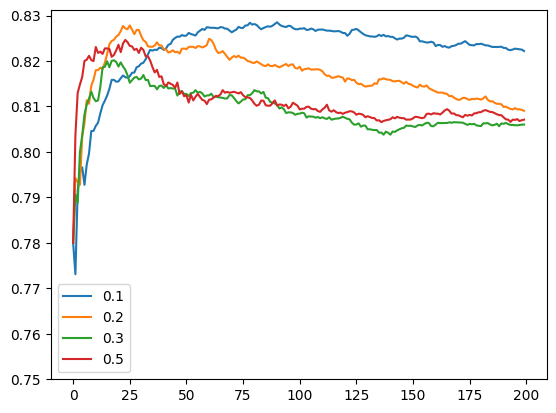

In [69]:
for k, results in results_opt.items():
    plt.plot(np.arange(len(results['val']['auc'])),results['val']['auc'], label=k)
plt.legend()
plt.ylim(0.75)

In [70]:
best_eta = 0.2

(0.75, 0.8446813470247754)

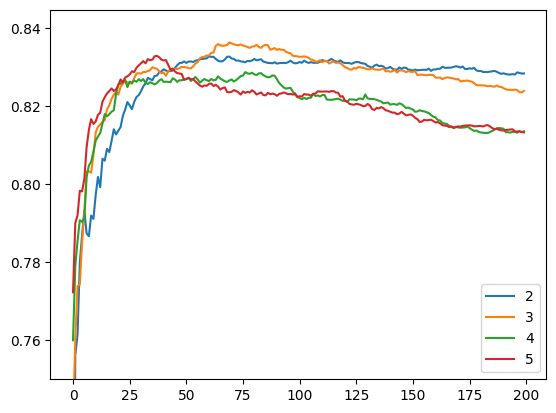

In [71]:
results_opt = {}

for depth in [2, 3, 4, 5]:
    
    xgb_params = {
        'eta': 0.2,
        'max_depth': depth,
        'min_child_weight':1,
        'objective': 'binary:logistic',
        'nthread':1,
        'eval_metric': 'auc',
        'seed':1,
        'verbosity':2,

    }

    results = {}
    model = xgb.train(xgb_params,
                    dtrain,
                    verbose_eval=None,
                    evals=watch_list,
                    evals_result=results,
                    num_boost_round=200)
    results_opt[depth] = deepcopy(results)

for k, results in results_opt.items():
    plt.plot(np.arange(len(results['val']['auc'])),results['val']['auc'], label=k)
plt.legend()
plt.ylim(0.75)

In [72]:
max_depth = 3

(0.75, 0.8416967377878957)

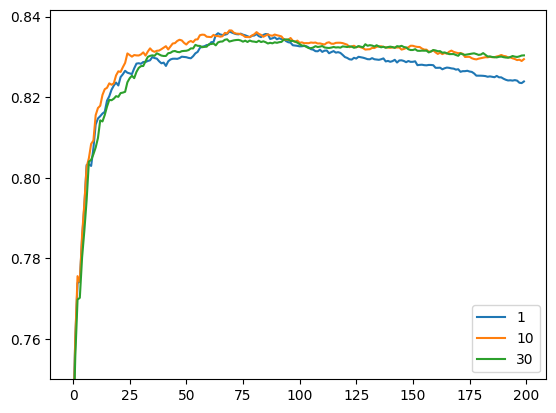

In [73]:
results_opt = {}

for mean_child_weight in [1, 10, 30]:
    
    xgb_params = {
        'eta': 0.2,
        'max_depth': 3,
        'min_child_weight':mean_child_weight,
        'objective': 'binary:logistic',
        'nthread':1,
        'eval_metric': 'auc',
        'seed':1,
        'verbosity':2,

    }

    results = {}
    model = xgb.train(xgb_params,
                    dtrain,
                    verbose_eval=None,
                    evals=watch_list,
                    evals_result=results,
                    num_boost_round=200)
    results_opt[mean_child_weight] = deepcopy(results)

for k, results in results_opt.items():
    plt.plot(np.arange(len(results['val']['auc'])),results['val']['auc'], label=k)
plt.legend()
plt.ylim(0.75)

In [74]:
mean_child_weight = 10

In [75]:

xgb_params = {
    'eta': 0.2,
    'max_depth': 3,
    'min_child_weight':10,
    'objective': 'binary:logistic',
    'nthread':1,
    'eval_metric': 'auc',
    'seed':1,
    'verbosity':2,

}

xgbboost = model = xgb.train(xgb_params,
                            dtrain,
                            verbose_eval=None,
                            num_boost_round=75)



## 6.09 Selecting the final model

In [ ]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100,
                            max_depth=3,
                            random_state=1,
                            min_samples_leaf=3,          
                        )
rf.fit(X_train, y_train)

xgb_params = {
    'eta': 0.2,
    'max_depth': 3,
    'min_child_weight':10,
    'objective': 'binary:logistic',
    'nthread':1,
    'eval_metric': 'auc',
    'seed':1,
    'verbosity':2,

}

xgbboost = xgb.train(xgb_params,
                            dtrain,
                            verbose_eval=None,
                            num_boost_round=75)


In [92]:
y_pred_dt = roc_auc_score(y_val, dt.predict_proba(X_val)[:,1])
y_pred_rf = roc_auc_score(y_val, rf.predict_proba(X_val)[:,1])
y_pred_xg = roc_auc_score(y_val, xgbboost.predict(dval))

In [90]:
print(y_pred_dt)
print(y_pred_rf)
print(y_pred_xg)

0.7853194400716863
0.7902599840158874
0.8356149039742318


In [95]:
df_full_train.reset_index(drop=True, inplace=True)

y_full_train = (df_full_train.status == 'default').astype(int).values
df_full_train_01 = df_full_train.copy()
del df_full_train_01['status']

In [98]:
dicts_full_train_01 = df_full_train_01.to_dict(orient='records')
dv = DictVectorizer(sparse=False)
X_full_train_01 = dv.fit_transform(dicts_full_train_01)

dicts_test = df_test.to_dict(orient='records')
X_test = dv.transform(dicts_test)

In [ ]:
d_full_train = xgb.DMatrix(X_full_train_01,
                           label=y_full_train,
                           feature_names = dv.get_feature_names_out().tolist())

d_test = xgb.DMatrix(X_test,
                    label=y_test,
                    feature_names = dv.get_feature_names_out().tolist())

In [105]:
xgb_params = {
    'eta': 0.2,
    'max_depth': 3,
    'min_child_weight':10,
    'objective': 'binary:logistic',
    'nthread':1,
    'eval_metric': 'auc',
    'seed':1,
    'verbosity':2,

}

xgbboost = xgb.train(xgb_params,
                            d_full_train,
                            verbose_eval=None,
                            num_boost_round=75)

In [107]:
y_pred = xgbboost.predict(d_test)
print(roc_auc_score(y_test, y_pred))

0.8286129710180342
